In [20]:
import matplotlib
matplotlib.rcParams["text.usetex"] = True
matplotlib.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}"
import matplotlib.gridspec as gridspec
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch
import math

In [21]:
def setup_graph():
    plt.xlim(-1, 8)
    plt.ylim(-1, 2)
    plt.xticks(range(8))
    plt.yticks([0, 1])
    plt.axhline(0, color="black", ls="--")
    plt.axvline(0, color="black", ls="--")

def configure_axes(ax):
    ax.axhline(color="black", ls="--")
    ax.axvline(color="black", ls="--")
    ax.set_xlim(-2, 5)
    ax.set_ylim(-1, 8)

# Save a figure to a file
def save_fig(fig, file_path,):
    # COMMENT OUT THIS LINE TO DISABLE SAVING
    fig.savefig(file_path, bbox_inches="tight")
    pass

import os
image_folder_name="generated_images"
os.makedirs(image_folder_name, exist_ok=True)

x = 3.5, f(x) = 2.5833333333333335
f'(x) = 1.6666666666666667


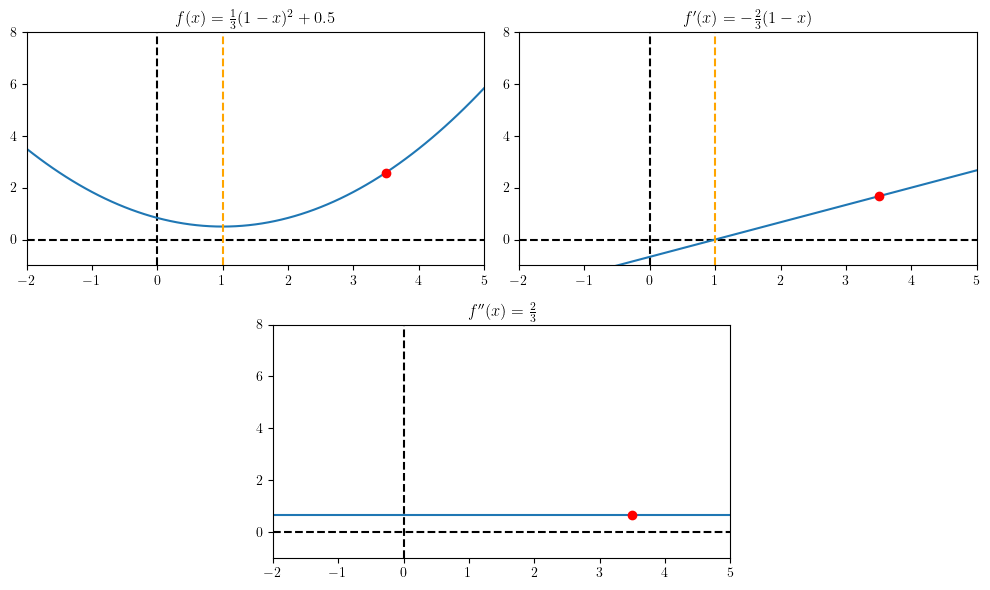

In [22]:
xs = [x/10 for x in range(-100, 100)]
ys= [((x-1)**2) /3 + 0.5 for x in xs]

fig = plt.figure(figsize=(10, 6))
gs = gridspec.GridSpec(2, 4, figure=fig)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[1, 1:3]) 
configure_axes(ax1)
configure_axes(ax2)
configure_axes(ax3)

ax1.set_title(r"$f(x) = \frac{1}{3}(1-x)^2 + 0.5$")
ax1.plot(xs, ys)
ax1.axvline(1, color="orange", ls="--")
ax1.plot(xs[-65], ys[-65], "ro-")
print(f"x = {xs[-65]}, f(x) = {ys[-65]}")

ax2.set_title(r"$f'(x) = -\frac{2}{3}(1-x)$")
ax2.plot(xs, [2*(x-1)/3 for x in xs])
y_val = 2*(xs[-65]-1)/3
ax2.plot(xs[-65], [y_val], "ro-")
ax2.axvline(1, color="orange", ls="--")
print(f"f'(x) = {y_val}")

ax3.set_title(r"$f''(x) = \frac{2}{3}$")
ax3.plot(xs, [2/3 for _ in xs])
ax3.plot(xs[-65], 2/3, "ro-")
plt.tight_layout()

save_fig(fig, f"{image_folder_name}/simple_quadratic.png")

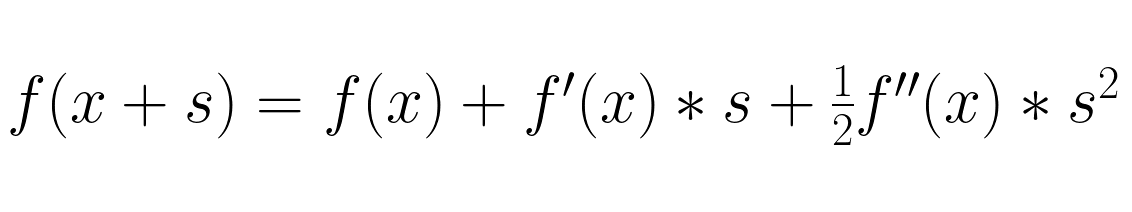

In [23]:
taylor_string = r"$f(x + s) = f(x) + f'(x)*s + \frac{1}{2} f''(x) * s^2$"

fig = plt.figure(figsize=(10, 2.5))  # Dimensions of figsize are in inches
plt.gca().axis("off")
fig.text(
    x=0.5,  # x-coordinate to place the text
    y=0.5,  # y-coordinate to place the text
    s=taylor_string,
    horizontalalignment="center",
    verticalalignment="center",
    fontsize=48,
)
save_fig(fig, f"{image_folder_name}/second_taylor.png")

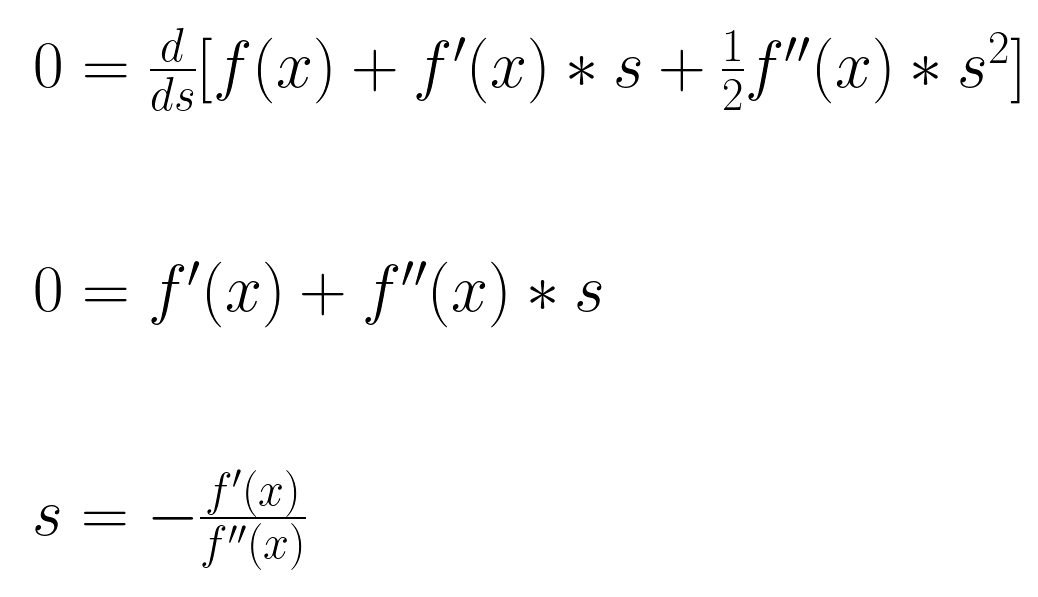

In [24]:
eq_1 = r"$0 = \frac{d}{ds}[f(x) + f'(x)*s + \frac{1}{2} f''(x) * s^2]$"
eq_2 = r"$0 = f'(x) + f''(x) * s$"
eq_3 = r"$s = -\frac{f'(x)}{f''(x)}$"

equations = [eq_1, eq_2, eq_3]

fig = plt.figure(figsize=(10, 7.5))
plt.gca().axis("off")
for (i, eq) in enumerate(equations):
        fig.text(
            x = 0.15,
            y= 0.8 - 0.3 * i,
            s=eq,
            horizontalalignment="left",
            verticalalignment="center",
            fontsize=48
        )
save_fig(fig, f"{image_folder_name}/step_calculation.png")

In [29]:
from manim import *
import numpy as np

# Inline preview size in the notebook.
config.media_width = "80%"
config.media_embed = True
config.quality = "high_quality" if os.getenv("CI") else "low_quality"

gradient_color = PURE_RED
newtonian_color = PURE_MAGENTA
cmap = "viridis"


In [26]:
# Requires pts to be in no more dimensions than the scene
def np_downsample(p, target_samples=300):
    pts = np.array([[r[0], r[1]] for r in p])
    s = np.diff(pts, axis=0) # Take the difference along axis 0, so each new row i is the element-wise difference of pts[i+1] and pts[i]
    s = np.linalg.norm(s, axis=1) # take the norm of each vector, i.e calculate euclidean distance between pts[i] and pts[i+1]
    s = np.cumsum(s) # the i'th element in `s` is now the traced-path distance from pts[0] to pts[i+1]
    s = np.concatenate(([0], s)) # prepend a 0, so now s is the traced-path distance from pts[0] to pts[i]
    targets = np.linspace(0, s[-1], target_samples) # take evenly spaced samples along the path-length traced by pts
    idxs = np.searchsorted(s, targets) # find the indexes of the elements of s with values closest to the values in targets
    idxs = np.clip(idxs, 0, len(pts)-1) # make sure we don't go out of bounds
    return pts[idxs]


weight = 0.15
def modified_easing(t):
    if t < weight:
        return weight * rate_functions.ease_in_quad(t / weight)
    return weight + (1 - weight) * rate_functions.ease_out_cubic((t-(weight)) /(1-weight))

In [27]:
%%manim -v WARNING GradientVsNewtonian
# The %%manim magic renders the named scene below and embeds the video inline.
#   -ql  = low quality / fast (use -qh for the final 1080p render)
#   The mp4 is also written under media/videos/...

starting_point = [-0.5, 1.25]

a, b = 1, 50
def surface_function(p):
    x, y = p
    rosenbrock = (a - x)**2 + b*(y-x**2)**2
    return rosenbrock

def record_position(p, p_list):
    p_list.append([*p.detach().tolist(), surface_function(p).item()])


p = torch.tensor(starting_point, requires_grad=True)
optimizer = torch.optim.SGD([p], lr=0.001)

positions_g = []
positions_n = []

record_position(p, positions_g)
record_position(p, positions_n)

ITERATIONS=12000

for _ in range(ITERATIONS):
    optimizer.zero_grad()
    loss = surface_function(p)
    loss.backward()
    optimizer.step()
    record_position(p, positions_g)


print("positions_g final: ", positions_g[-1])
positions_g = [(x, y) for (x, y, _) in positions_g]
positions_g = np_downsample(positions_g)

# print("positions_g len: ", len(positions_g))

p = torch.tensor(starting_point, requires_grad=True)

for _ in range(5):
    gradients = torch.autograd.functional.jacobian(surface_function, p)
    hessian = torch.autograd.functional.hessian(surface_function, p)
    step = torch.linalg.solve(hessian, gradients) # find x that solves for B x = df
    with torch.no_grad():
        p -= step
    record_position(p, positions_n)



# print("graident: ", positions_g[-5:])
# print("newtonian: ", positions_n)
# print("newton finite:", np.isfinite(positions_n).all())
# print("grad  finite:", np.isfinite(positions_g).all())
# print(positions_g)
def surface_numpy(x, y):
    return (a - x)**2 + b*(y-x**2)**2


class GradientVsNewtonian(Scene):
    # ThreeDScene gives you a movable 3D camera. construct() is the "script":
    # everything you add()/play() here becomes the animation, in order.
    def construct(self):
        # ThreeDAxes draws the x/y/z frame. Ranges are [min, max, step].
        x_range = [-1.5, 1.5]
        y_range = [-2, 3]
        axes = Axes(x_range=x_range, y_range=y_range)

        def make_heatmap(res=400):
            xs = np.linspace(x_range[0], x_range[1], res)
            ys = np.linspace(y_range[0], y_range[1], res)
            X, Y = np.meshgrid(xs, ys)
            Z = surface_numpy(X, Y)
            Z = np.log(Z + 1)
            Z = (Z-Z.min()) / (Z.max() - Z.min())
            rgba = (matplotlib.colormaps[cmap](Z, bytes=True))
            rgba = np.flipud(rgba)
            lo, hi = axes.c2p(x_range[0], y_range[0]), axes.c2p(x_range[1], y_range[1])
            img = ImageMobject(rgba)
            img.stretch_to_fit_width(abs(hi[0] - lo[0]))
            img.stretch_to_fit_height(abs(hi[1] - lo[1]))
            img.move_to(axes.c2p(np.mean(x_range), np.mean(y_range)))
            border = SurroundingRectangle(img, color=WHITE, buff=0, stroke_width=1)
            return Group(img, border)
        

        heat = make_heatmap()

        def make_legend(res=256):
            ramp = np.linspace(1, 0, res).reshape(res, 1)
            rgba = matplotlib.colormaps[cmap](ramp, bytes=True)

            bar = ImageMobject(rgba)
            bar.stretch_to_fit_height(heat.height * 0.8)
            bar.stretch_to_fit_width(0.4)
            bar.next_to(heat, RIGHT, buff=0.6)

            border = SurroundingRectangle(bar, color=WHITE, buff=0, stroke_width=1)
            high = Text("High", font_size=22).next_to(bar, UP, buff=0.15)
            low = Text("Low", font_size=22 ).next_to(bar, DOWN, buff=0.15)
            return Group(bar, border, high, low)
        
        legend = make_legend()

        gradient_coords = [axes.c2p(x, y) for (x, y) in positions_g]
        newtonian_coords = [axes.c2p(x, y) for (x, y, z) in positions_n]

        gradient_path = VMobject().set_points_as_corners(gradient_coords)
        newtonian_path = VMobject().set_points_as_corners(newtonian_coords)

        self.add(heat)
        # self.add(axes)
        self.add(legend)


        minimum = Dot(point=newtonian_coords[-1], color=BLACK, stroke_width=2, stroke_color=WHITE)
        min_text = Text("Minimum", font_size=36, fill_color=BLACK, stroke_color=WHITE, stroke_width=2, weight=BOLD).next_to(heat, UP, buff=0.15)
        self.play(Create(minimum, run_time=1.5), Create(min_text))
        self.wait()
        self.play(FadeOut(min_text, run_time=0.5))
        self.wait(0.5)

        gd = Dot(point=[gradient_coords[0]], color=gradient_color, stroke_width=1, stroke_color=BLACK)
        gd_text = Text("Gradient Descent", font_size=36, fill_color=gradient_color, stroke_color=WHITE, stroke_width=1, weight=BOLD).next_to(heat, UP, buff=0.15)
        self.play(Create(gd, run_time=1.5), Create(gd_text))
        self.wait()

        gd_trace = TracedPath(gd.get_center, stroke_color=gradient_color, stroke_width=4)
        self.add(gd_trace)
        self.play(MoveAlongPath(gd, gradient_path, rate_func=modified_easing, run_time=5))

        self.play(FadeOut(gd_text, run_time=0.5))
        self.wait(0.5)

        nd = Dot(point=[newtonian_coords[0]], color=newtonian_color, stroke_width=1, stroke_color=BLACK)
        nd_text = Text("Newtonian Optimization", font_size=36, color=newtonian_color, stroke_color=WHITE, stroke_width=1, weight=BOLD).next_to(heat, UP, buff=0.15)
        self.play(Create(nd, run_time=1.5), Create(nd_text))
        self.wait()


        self.add(Dot(point=gradient_coords[0], color=newtonian_color, fill_opacity=0.7))
        for i in range(1,len(newtonian_coords)):
            partial_path = VMobject().set_points_as_corners(newtonian_coords[i-1:i+1])
            self.play(MoveAlongPath(nd, partial_path, rate_func=rate_functions.ease_in_out_cubic, run_time=1))
            self.add(Dot(point=newtonian_coords[i], color=newtonian_color, fill_opacity=0.7, stroke_width=1, stroke_color=BLACK))
        


        self.wait()

positions_g final:  [0.9966963529586792, 0.993377149105072, 1.0949102033919189e-05]


Manim Community v0.20.1

In [ ]:
%%manim -v WARNING SinusoidalValley
# The %%manim magic renders the named scene below and embeds the video inline.
#   -ql  = low quality / fast (use -qh for the final 1080p render)
#   The mp4 is also written under media/videos/...

starting_point = [-0.5, 1.25]

a, b = 1, 50
def surface_function(p):
    x, y = p
    return torch.sin(x) + torch.sin(y)

def record_position(p, p_list):
    p_list.append([*p.detach().tolist(), surface_function(p).item()])


p = torch.tensor(starting_point, requires_grad=True)
optimizer = torch.optim.SGD([p], lr=0.001)

positions_g = []
positions_n = []

record_position(p, positions_g)
record_position(p, positions_n)

ITERATIONS=12000

for _ in range(ITERATIONS):
    optimizer.zero_grad()
    loss = surface_function(p)
    loss.backward()
    optimizer.step()
    record_position(p, positions_g)


print("positions_g final: ", positions_g[-1])
positions_g = [(x, y) for (x, y, _) in positions_g]
positions_g = np_downsample(positions_g)

# print("positions_g len: ", len(positions_g))

p = torch.tensor(starting_point, requires_grad=True)

for _ in range(3):
    gradients = torch.autograd.functional.jacobian(surface_function, p)
    hessian = torch.autograd.functional.hessian(surface_function, p)
    step = torch.linalg.solve(hessian, gradients) # find x that solves for B x = df
    with torch.no_grad():
        p -= step
    record_position(p, positions_n)



# print("graident: ", positions_g[-5:])
print("newtonian: ", positions_n)
# print("newton finite:", np.isfinite(positions_n).all())
# print("grad  finite:", np.isfinite(positions_g).all())
# print(positions_g)
def surface_numpy(x, y):
    return np.sin(x) + np.sin(y)


class SinusoidalValley(Scene):
    # ThreeDScene gives you a movable 3D camera. construct() is the "script":
    # everything you add()/play() here becomes the animation, in order.
    def construct(self):
        # ThreeDAxes draws the x/y/z frame. Ranges are [min, max, step].
        x_range = [-3, 3]
        y_range = [-3, 3]
        axes = Axes(x_range=x_range, y_range=y_range)

        def make_heatmap(res=400):
            xs = np.linspace(x_range[0], x_range[1], res)
            ys = np.linspace(y_range[0], y_range[1], res)
            X, Y = np.meshgrid(xs, ys)
            Z = surface_numpy(X, Y)
            Z = (Z-Z.min()) / (Z.max() - Z.min())
            rgba = (matplotlib.colormaps[cmap](Z, bytes=True))
            rgba = np.flipud(rgba)
            lo, hi = axes.c2p(x_range[0], y_range[0]), axes.c2p(x_range[1], y_range[1])
            img = ImageMobject(rgba)
            img.stretch_to_fit_width(abs(hi[0] - lo[0]))
            img.stretch_to_fit_height(abs(hi[1] - lo[1]))
            img.move_to(axes.c2p(np.mean(x_range), np.mean(y_range)))
            border = SurroundingRectangle(img, color=WHITE, buff=0, stroke_width=1)
            return Group(img, border)
        

        heat = make_heatmap()

        def make_legend(res=256):
            ramp = np.linspace(1, 0, res).reshape(res, 1)
            rgba = matplotlib.colormaps[cmap](ramp, bytes=True)

            bar = ImageMobject(rgba)
            bar.stretch_to_fit_height(heat.height * 0.8)
            bar.stretch_to_fit_width(0.4)
            bar.next_to(heat, RIGHT, buff=0.6)

            border = SurroundingRectangle(bar, color=WHITE, buff=0, stroke_width=1)
            high = Text("High", font_size=22).next_to(bar, UP, buff=0.15)
            low = Text("Low", font_size=22 ).next_to(bar, DOWN, buff=0.15)
            return Group(bar, border, high, low)
        
        legend = make_legend()

        gradient_coords = [axes.c2p(x, y) for (x, y) in positions_g]
        newtonian_coords = [axes.c2p(x, y) for (x, y, z) in positions_n]

        gradient_path = VMobject().set_points_as_corners(gradient_coords)
        newtonian_path = VMobject().set_points_as_corners(newtonian_coords)

        self.add(heat)
        # self.add(axes)
        self.add(legend)


        minimum = Dot(point=axes.c2p([math.pi * -0.5, math.pi * -0.5]), color=BLACK, stroke_width=2, stroke_color=WHITE)
        min_text = Text("Minimum", font_size=36, fill_color=BLACK, stroke_color=WHITE, stroke_width=2, weight=BOLD).next_to(heat, UP, buff=0.15)
        self.play(Create(minimum, run_time=1.5), Create(min_text))
        self.wait()
        self.play(FadeOut(min_text, run_time=0.5))
        self.wait(0.5)

        gd = Dot(point=[gradient_coords[0]], color=gradient_color, stroke_width=1, stroke_color=BLACK)
        gd_text = Text("Gradient Descent", font_size=36, fill_color=gradient_color, stroke_color=WHITE, stroke_width=1, weight=BOLD).next_to(heat, UP, buff=0.15)
        self.play(Create(gd, run_time=1.5), Create(gd_text))
        self.wait()

        gd_trace = TracedPath(gd.get_center, stroke_color=gradient_color, stroke_width=4)
        self.add(gd_trace)
        self.play(MoveAlongPath(gd, gradient_path, rate_func=modified_easing, run_time=5))

        self.play(FadeOut(gd_text, run_time=0.5))
        self.wait(0.5)

        nd = Dot(point=[newtonian_coords[0]], color=newtonian_color, stroke_width=1, stroke_color=BLACK)
        nd_text = Text("Newtonian Optimization", font_size=36, color=newtonian_color, stroke_color=WHITE, stroke_width=1, weight=BOLD).next_to(heat, UP, buff=0.15)
        self.play(Create(nd, run_time=1.5), Create(nd_text))
        self.wait()


        self.add(Dot(point=gradient_coords[0], color=newtonian_color, fill_opacity=0.7))
        for i in range(1,len(newtonian_coords)):
            partial_path = VMobject().set_points_as_corners(newtonian_coords[i-1:i+1])
            self.play(MoveAlongPath(nd, partial_path, rate_func=rate_functions.ease_in_out_cubic, run_time=1))
            self.add(Dot(point=newtonian_coords[i], color=newtonian_color, fill_opacity=0.7, stroke_width=1, stroke_color=BLACK))
        


        self.wait()

positions_g final:  [-1.5707367658615112, -1.5707221031188965, -2.0]
newtonian:  [[-0.5, 1.25, 0.46955907344818115], [-2.3304877281188965, 1.5822734832763672, 0.27488553524017334], [-1.380623459815979, 1.5707957744598389, 0.018028438091278076], [-1.573122501373291, 1.5707963705062866, 2.682209014892578e-06]]


Manim Community v0.20.1